In [219]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [220]:
# read the original data
children = pd.read_csv('child24.csv')


In [221]:
# AGEP_C: limite the range of age of surveyed children

children_with_range = children[5 <= children['AGEP_C']]
children_with_range = children_with_range[children_with_range['AGEP_C'] <= 17]

In [222]:
# Demographics

# RELTIV_C
# NEWSEX_C
# NEWATORG_C
# NEWRACE_C

In [223]:
# Children who have food allergy
children_with_food_allergy = children_with_range[children_with_range["CURFOOD_C"] == 1]
children_with_food_allergy

# children_with_range
children_with_food_allergy["AGEP_C"].value_counts().sort_index()

5     23
6     29
7     37
8     28
9     40
10    44
11    30
12    45
13    39
14    40
15    60
16    53
17    57
Name: AGEP_C, dtype: int64

In [224]:
# demographic questions

demographic_guestions_1 = [
    "SEX_C", "RELTIVP_C", "HISP_C",
    "RACEALLP_C"
]

children_with_food_allergy_demographics_1 = children_with_food_allergy[demographic_guestions_1]
children_with_food_allergy_demographics_1

,SEX_C,RELTIVP_C,HISP_C,RACEALLP_C
30,2,1,2,1
53,2,1,1,8
61,1,1,1,1
62,1,1,1,8
68,2,1,2,3
...,...,...,...,...
8250,1,1,2,3
8263,1,1,1,1
8279,2,1,1,4
8326,1,1,2,2


In [225]:
# HEALTH QUESTIONS

health_questions = [
    "AGEP_C", "PHSTAT_C", "CURFOOD_C",
    "ANXFREQ_C", "DEPFREQ_C", "SCHDYMSSTC_C",
    "LASTDR_C", "MEDDL12M_C", "EMERG12MTC_C",
    "MEDNG12M_C", "RXDL12M_C", "RXDG12M_C"
]

children_with_food_allergy_health = children_with_food_allergy[health_questions]

children_with_food_allergy_health.to_csv("child_food_allergy_health_vars.csv")
children_with_food_allergy_health

,AGEP_C,PHSTAT_C,CURFOOD_C,ANXFREQ_C,DEPFREQ_C,SCHDYMSSTC_C,LASTDR_C,MEDDL12M_C,EMERG12MTC_C,MEDNG12M_C,RXDL12M_C,RXDG12M_C
30,8,1,1,5.0,5.0,0.0,1,2,0,2,NaN,2
53,11,3,1,3.0,5.0,0.0,1,2,0,2,NaN,2
61,17,4,1,5.0,5.0,10.0,1,2,0,2,2.0,2
62,6,1,1,5.0,5.0,5.0,1,2,2,2,2.0,2
68,7,3,1,5.0,5.0,30.0,2,2,0,2,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...
8250,11,1,1,4.0,5.0,5.0,1,2,0,2,2.0,2
8263,15,3,1,4.0,5.0,6.0,1,1,0,2,NaN,2
8279,15,3,1,3.0,3.0,1.0,1,2,1,2,NaN,2
8326,11,2,1,5.0,5.0,0.0,1,2,0,2,2.0,2


In [226]:
## demographics_1 + health questions

combined = pd.concat(
    [children_with_food_allergy_health, children_with_food_allergy_demographics_1],
    axis=1
)

combined

,AGEP_C,PHSTAT_C,CURFOOD_C,ANXFREQ_C,DEPFREQ_C,SCHDYMSSTC_C,LASTDR_C,MEDDL12M_C,EMERG12MTC_C,MEDNG12M_C,RXDL12M_C,RXDG12M_C,SEX_C,RELTIVP_C,HISP_C,RACEALLP_C
30,8,1,1,5.0,5.0,0.0,1,2,0,2,NaN,2,2,1,2,1
53,11,3,1,3.0,5.0,0.0,1,2,0,2,NaN,2,2,1,1,8
61,17,4,1,5.0,5.0,10.0,1,2,0,2,2.0,2,1,1,1,1
62,6,1,1,5.0,5.0,5.0,1,2,2,2,2.0,2,1,1,1,8
68,7,3,1,5.0,5.0,30.0,2,2,0,2,NaN,2,2,1,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8250,11,1,1,4.0,5.0,5.0,1,2,0,2,2.0,2,1,1,2,3
8263,15,3,1,4.0,5.0,6.0,1,1,0,2,NaN,2,1,1,1,1
8279,15,3,1,3.0,3.0,1.0,1,2,1,2,NaN,2,2,1,1,4
8326,11,2,1,5.0,5.0,0.0,1,2,0,2,2.0,2,1,1,2,2


In [227]:
## PARENTAL DEMOGRAPHICS, citizenship, employment, income, income above or below poverty level

demographic_questions_2 = [
    "HICOV_C", "PAYBLL12M_C", "PAYNOBLLNW_C",
    "PAYWORRY_C", "PCNTADWKP1_C", "INCWRKO_C", "SSISSDIDSB_C",
    "INCWELF_C", "POVRATTC_C", "RATCAT_C", "FSNAP12M_C", 
    "FWIC12M_C", "FLUNCH12M1_C", "MAXPAREDUP_C"
]

children_with_food_allergy_demographics_2 = children_with_food_allergy[demographic_questions_2]

# children_with_food_allergy_demographics.to_csv("children_with_food_allergy_demographics.csv")
children_with_food_allergy_demographics_2


,HICOV_C,PAYBLL12M_C,PAYNOBLLNW_C,PAYWORRY_C,PCNTADWKP1_C,INCWRKO_C,SSISSDIDSB_C,INCWELF_C,POVRATTC_C,RATCAT_C,FSNAP12M_C,FWIC12M_C,FLUNCH12M1_C,MAXPAREDUP_C
30,1,2,NaN,3,1,1,NaN,2.0,0.52,2,1,NaN,1.0,6.0
53,1,2,NaN,2,1,1,NaN,1.0,1.29,5,1,2.0,2.0,5.0
61,1,8,NaN,2,7,8,NaN,NaN,1.43,5,8,8.0,NaN,5.0
62,1,2,NaN,2,2,1,NaN,2.0,2.88,9,2,1.0,1.0,1.0
68,1,2,NaN,2,1,1,NaN,2.0,2.23,8,2,2.0,1.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8250,1,1,1.0,2,2,1,NaN,2.0,4.02,12,2,2.0,2.0,8.0
8263,1,2,NaN,1,3,2,NaN,2.0,1.60,6,1,2.0,1.0,1.0
8279,1,2,NaN,3,1,1,NaN,1.0,0.70,2,1,1.0,1.0,5.0
8326,1,2,NaN,3,2,1,NaN,2.0,3.26,10,2,2.0,1.0,5.0


In [228]:
# Demographics_1 + Health Questions + Demographics_2

combined = pd.concat(
    [combined, children_with_food_allergy_demographics_2],
    axis=1
)

combined = combined.loc[:, ~combined.columns.duplicated()]
combined

,AGEP_C,PHSTAT_C,CURFOOD_C,ANXFREQ_C,DEPFREQ_C,SCHDYMSSTC_C,LASTDR_C,MEDDL12M_C,EMERG12MTC_C,MEDNG12M_C,...,PCNTADWKP1_C,INCWRKO_C,SSISSDIDSB_C,INCWELF_C,POVRATTC_C,RATCAT_C,FSNAP12M_C,FWIC12M_C,FLUNCH12M1_C,MAXPAREDUP_C
30,8,1,1,5.0,5.0,0.0,1,2,0,2,...,1,1,NaN,2.0,0.52,2,1,NaN,1.0,6.0
53,11,3,1,3.0,5.0,0.0,1,2,0,2,...,1,1,NaN,1.0,1.29,5,1,2.0,2.0,5.0
61,17,4,1,5.0,5.0,10.0,1,2,0,2,...,7,8,NaN,NaN,1.43,5,8,8.0,NaN,5.0
62,6,1,1,5.0,5.0,5.0,1,2,2,2,...,2,1,NaN,2.0,2.88,9,2,1.0,1.0,1.0
68,7,3,1,5.0,5.0,30.0,2,2,0,2,...,1,1,NaN,2.0,2.23,8,2,2.0,1.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8250,11,1,1,4.0,5.0,5.0,1,2,0,2,...,2,1,NaN,2.0,4.02,12,2,2.0,2.0,8.0
8263,15,3,1,4.0,5.0,6.0,1,1,0,2,...,3,2,NaN,2.0,1.60,6,1,2.0,1.0,1.0
8279,15,3,1,3.0,3.0,1.0,1,2,1,2,...,1,1,NaN,1.0,0.70,2,1,1.0,1.0,5.0
8326,11,2,1,5.0,5.0,0.0,1,2,0,2,...,2,1,NaN,2.0,3.26,10,2,2.0,1.0,5.0


In [229]:
# Food Security

children_with_food_allergy_food_security = children_with_food_allergy[["FDSLAST_C", "FDSRUNOUT_C"]]

children_with_food_allergy_food_security

,FDSLAST_C,FDSRUNOUT_C
30,2,3
53,2,3
61,8,8
62,3,3
68,3,3
...,...,...
8250,3,3
8263,1,2
8279,3,3
8326,3,3


In [230]:
# Demographics_1 + Health Questions + Demographics_2 + Food_Security

combined = pd.concat(
    [combined, children_with_food_allergy_food_security],
    axis=1
)

combined

,AGEP_C,PHSTAT_C,CURFOOD_C,ANXFREQ_C,DEPFREQ_C,SCHDYMSSTC_C,LASTDR_C,MEDDL12M_C,EMERG12MTC_C,MEDNG12M_C,...,SSISSDIDSB_C,INCWELF_C,POVRATTC_C,RATCAT_C,FSNAP12M_C,FWIC12M_C,FLUNCH12M1_C,MAXPAREDUP_C,FDSLAST_C,FDSRUNOUT_C
30,8,1,1,5.0,5.0,0.0,1,2,0,2,...,NaN,2.0,0.52,2,1,NaN,1.0,6.0,2,3
53,11,3,1,3.0,5.0,0.0,1,2,0,2,...,NaN,1.0,1.29,5,1,2.0,2.0,5.0,2,3
61,17,4,1,5.0,5.0,10.0,1,2,0,2,...,NaN,NaN,1.43,5,8,8.0,NaN,5.0,8,8
62,6,1,1,5.0,5.0,5.0,1,2,2,2,...,NaN,2.0,2.88,9,2,1.0,1.0,1.0,3,3
68,7,3,1,5.0,5.0,30.0,2,2,0,2,...,NaN,2.0,2.23,8,2,2.0,1.0,4.0,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8250,11,1,1,4.0,5.0,5.0,1,2,0,2,...,NaN,2.0,4.02,12,2,2.0,2.0,8.0,3,3
8263,15,3,1,4.0,5.0,6.0,1,1,0,2,...,NaN,2.0,1.60,6,1,2.0,1.0,1.0,1,2
8279,15,3,1,3.0,3.0,1.0,1,2,1,2,...,NaN,1.0,0.70,2,1,1.0,1.0,5.0,3,3
8326,11,2,1,5.0,5.0,0.0,1,2,0,2,...,NaN,2.0,3.26,10,2,2.0,1.0,5.0,3,3


In [231]:
# Family Income

family_income = [
    "INCRETIRE_C", "INCOTHR_C",
]

children_with_food_allergy_family_income = children_with_food_allergy[family_income]

In [232]:
# Health Questions + Demographics + Food Security + Family Income

combined = pd.concat(
    [combined, children_with_food_allergy_family_income],
    axis=1
)

combined

combined.to_csv("child_food_allergy.csv")

In [233]:
combined

,AGEP_C,PHSTAT_C,CURFOOD_C,ANXFREQ_C,DEPFREQ_C,SCHDYMSSTC_C,LASTDR_C,MEDDL12M_C,EMERG12MTC_C,MEDNG12M_C,...,POVRATTC_C,RATCAT_C,FSNAP12M_C,FWIC12M_C,FLUNCH12M1_C,MAXPAREDUP_C,FDSLAST_C,FDSRUNOUT_C,INCRETIRE_C,INCOTHR_C
30,8,1,1,5.0,5.0,0.0,1,2,0,2,...,0.52,2,1,NaN,1.0,6.0,2,3,2.0,2.0
53,11,3,1,3.0,5.0,0.0,1,2,0,2,...,1.29,5,1,2.0,2.0,5.0,2,3,2.0,2.0
61,17,4,1,5.0,5.0,10.0,1,2,0,2,...,1.43,5,8,8.0,NaN,5.0,8,8,NaN,NaN
62,6,1,1,5.0,5.0,5.0,1,2,2,2,...,2.88,9,2,1.0,1.0,1.0,3,3,2.0,2.0
68,7,3,1,5.0,5.0,30.0,2,2,0,2,...,2.23,8,2,2.0,1.0,4.0,3,3,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8250,11,1,1,4.0,5.0,5.0,1,2,0,2,...,4.02,12,2,2.0,2.0,8.0,3,3,2.0,2.0
8263,15,3,1,4.0,5.0,6.0,1,1,0,2,...,1.60,6,1,2.0,1.0,1.0,1,2,2.0,2.0
8279,15,3,1,3.0,3.0,1.0,1,2,1,2,...,0.70,2,1,1.0,1.0,5.0,3,3,2.0,2.0
8326,11,2,1,5.0,5.0,0.0,1,2,0,2,...,3.26,10,2,2.0,1.0,5.0,3,3,2.0,2.0


In [234]:
# 나이대별 음식알러지 건수 테이블
# 설명: combined 데이터에서 나이대(age_group)별 음식알러지 건수(allergy_n)만 간단히 집계합니다.
if "combined" not in globals():
    raise ValueError("combined 변수가 없습니다. 위쪽 결합 셀을 먼저 실행하세요.")

age_bins = [4, 7, 10, 13, 17]
age_labels = ["5-7", "8-10", "11-13", "14-17"]

age_group_table = (
    combined[combined["AGEP_C"].between(5, 17)]
    .assign(age_group=lambda d: pd.cut(d["AGEP_C"], bins=age_bins, labels=age_labels, include_lowest=True))
    .groupby("age_group", observed=False)
    .size()
    .reset_index(name="allergy_n")
)

age_group_table


,age_group,allergy_n
0,5-7,89
1,8-10,112
2,11-13,114
3,14-17,210


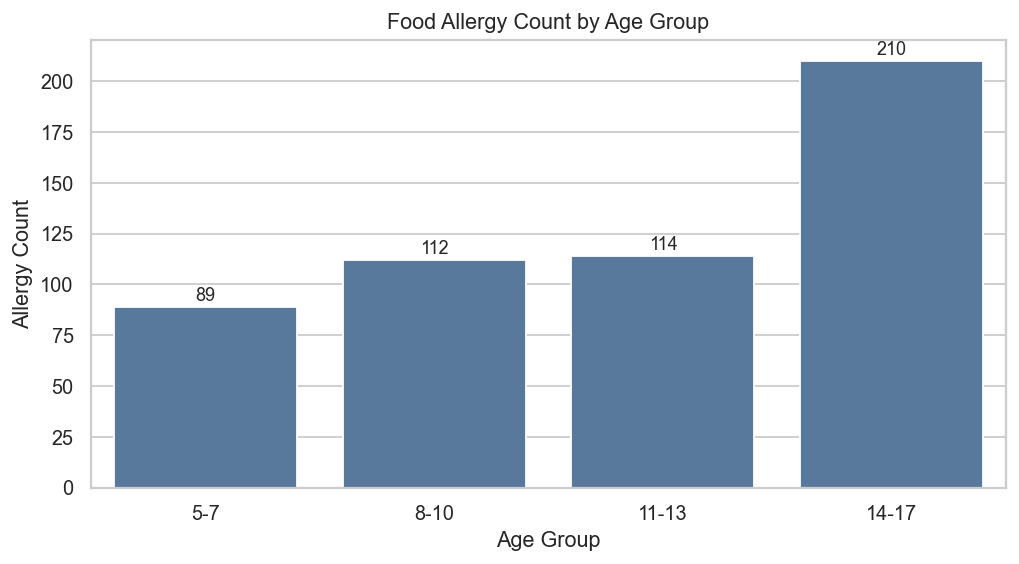

In [235]:
# 나이대별 음식알러지 건수 막대그래프
# 설명: age_group_table을 이용해 나이대별 allergy_n을 간단한 bar chart로 시각화합니다.

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 4.5))
ax = sns.barplot(
    data=age_group_table,
    x="age_group",
    y="allergy_n",
    color="#4C78A8"
)

for i, v in enumerate(age_group_table["allergy_n"]):
    ax.text(i, v + 1, str(int(v)), ha="center", va="bottom", fontsize=10)

ax.set_title("Food Allergy Count by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Allergy Count")
plt.tight_layout()
plt.show()

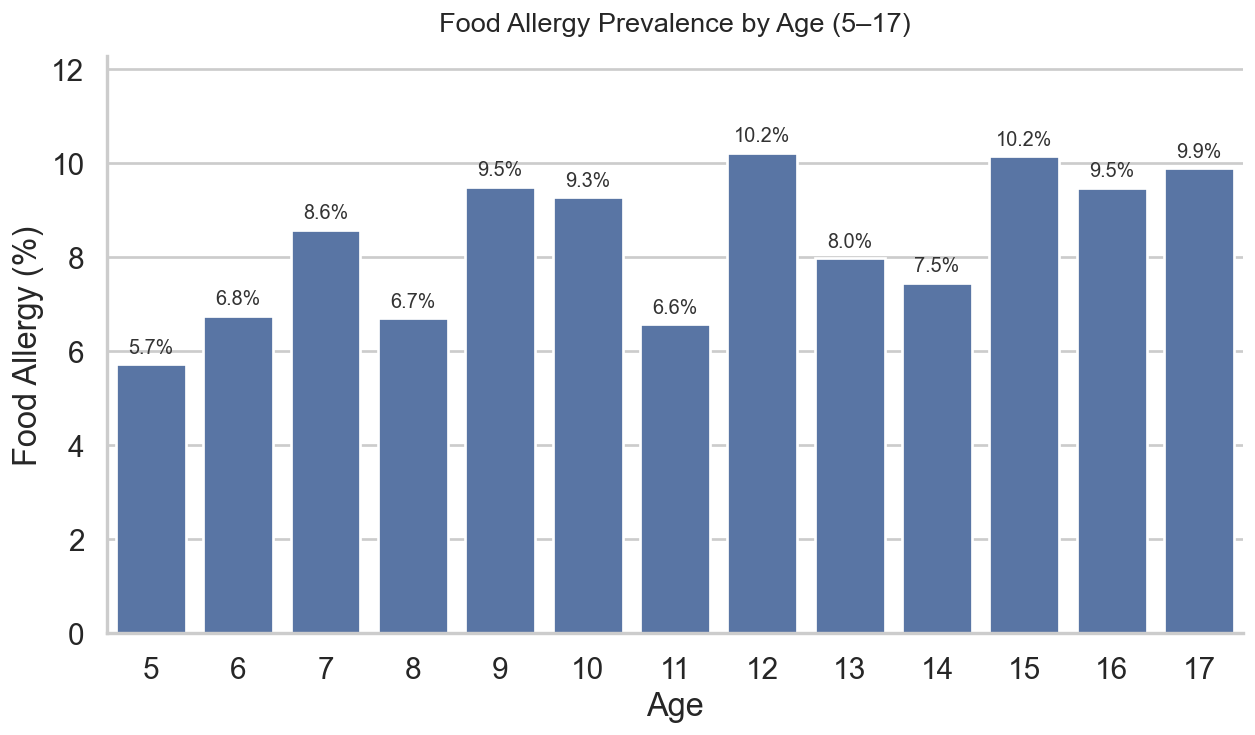

In [236]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

age_df = df.loc[df["AGEP_C"].between(5, 17), ["AGEP_C", "food_allergy"]].dropna()
age_rate = (
    age_df.groupby("AGEP_C")["food_allergy"]
    .mean()
    .reindex(range(5, 18))
    .mul(100)
    .reset_index(name="food_allergy_pct")
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = sns.barplot(
    data=age_rate,
    x="AGEP_C",
    y="food_allergy_pct",
    color="#4C72B0",
    ax=ax
)

ax.bar_label(
    ax.containers[0],
    fmt="%.1f%%",
    padding=4,
    fontsize=11,
    color="#333333"
)

ax.set_title("Food Allergy Prevalence by Age (5–17)", fontsize=15, pad=14)
ax.set_xlabel("Age")
ax.set_ylabel("Food Allergy (%)")
ax.set_ylim(0, max(5, age_rate["food_allergy_pct"].max() * 1.2))
plt.tight_layout()
plt.show()

In [237]:
print(combined.columns.tolist())

['AGEP_C', 'PHSTAT_C', 'CURFOOD_C', 'ANXFREQ_C', 'DEPFREQ_C', 'SCHDYMSSTC_C', 'LASTDR_C', 'MEDDL12M_C', 'EMERG12MTC_C', 'MEDNG12M_C', 'RXDL12M_C', 'RXDG12M_C', 'SEX_C', 'RELTIVP_C', 'HISP_C', 'RACEALLP_C', 'HICOV_C', 'PAYBLL12M_C', 'PAYNOBLLNW_C', 'PAYWORRY_C', 'PCNTADWKP1_C', 'INCWRKO_C', 'SSISSDIDSB_C', 'INCWELF_C', 'POVRATTC_C', 'RATCAT_C', 'FSNAP12M_C', 'FWIC12M_C', 'FLUNCH12M1_C', 'MAXPAREDUP_C', 'FDSLAST_C', 'FDSRUNOUT_C', 'INCRETIRE_C', 'INCOTHR_C']


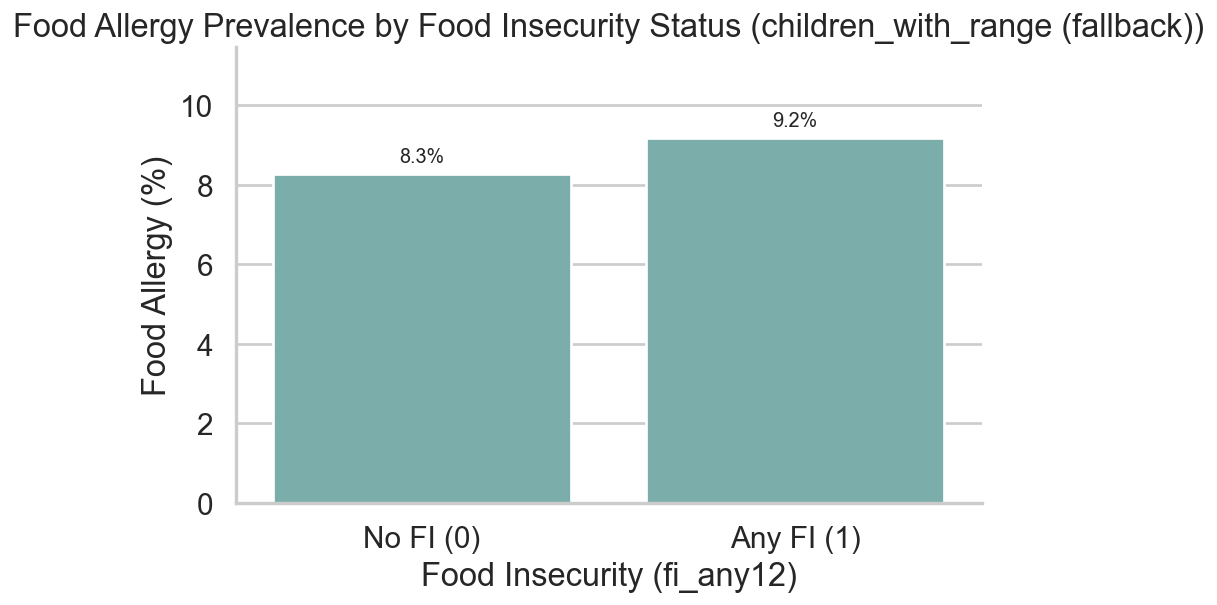

In [245]:
# Visualization 2: Food Allergy by Food Insecurity Status
# Uses combined first, with optional fallback to children_with_range.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 300,
    "axes.spines.top": False, "axes.spines.right": False
})

def prep(df):
    out = df.copy()

    # food_allergy
    out["food_allergy"] = pd.to_numeric(out["CURFOOD_C"], errors="coerce").map({1: 1, 2: 0})

    # fi_any12
    if "fi_any12" not in out.columns:
        if "fi_fdslast12" not in out.columns and "FDSLAST_C" in out.columns:
            out["fi_fdslast12"] = pd.to_numeric(out["FDSLAST_C"], errors="coerce").map({1: 1, 2: 1, 3: 0})
        if "fi_fdsrunout12" not in out.columns and "FDSRUNOUT_C" in out.columns:
            out["fi_fdsrunout12"] = pd.to_numeric(out["FDSRUNOUT_C"], errors="coerce").map({1: 1, 2: 1, 3: 0})
        if {"fi_fdslast12", "fi_fdsrunout12"}.issubset(out.columns):
            out["fi_any12"] = out[["fi_fdslast12", "fi_fdsrunout12"]].max(axis=1)
        else:
            raise KeyError("Need fi_any12 or FDSLAST/FDSRUNOUT columns")
    else:
        out["fi_any12"] = pd.to_numeric(out["fi_any12"], errors="coerce")

    out = out[["food_allergy", "fi_any12"]].dropna()
    return out[out["food_allergy"].isin([0, 1]) & out["fi_any12"].isin([0, 1])]

# combined 우선, food_allergy가 한 클래스면 fallback
analysis_df, source_name = prep(combined), "combined"
if analysis_df["food_allergy"].nunique() < 2 and "children_with_range" in globals():
    alt = prep(children_with_range)
    if alt["food_allergy"].nunique() >= 2:
        analysis_df, source_name = alt, "children_with_range (fallback)"

fi_rate = (analysis_df.groupby("fi_any12")["food_allergy"].mean()
           .reindex([0, 1]).mul(100).reset_index(name="food_allergy_pct"))
fi_rate["label"] = fi_rate["fi_any12"].map({0: "No FI (0)", 1: "Any FI (1)"})

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=fi_rate, x="label", y="food_allergy_pct", color="#72B7B2", ax=ax)

for i, v in enumerate(fi_rate["food_allergy_pct"]):
    if pd.notna(v):
        ax.text(i, v + 0.2, f"{v:.1f}%", ha="center", va="bottom", fontsize=11)

ax.set(
    title=f"Food Allergy Prevalence by Food Insecurity Status ({source_name})",
    xlabel="Food Insecurity (fi_any12)", ylabel="Food Allergy (%)"
)
ax.set_ylim(0, max(5, fi_rate["food_allergy_pct"].max() * 1.25))
plt.tight_layout()
plt.show()


In [239]:
# Analysis: Association between fi_any12 and food_allergy
# Builds 2x2 table, runs chi-square test, and reports prevalence by FI status.
import pandas as pd
from scipy.stats import chi2_contingency

# 1) Prepare analysis dataframe (use df if present, else combined)
source_df = df.copy() if 'df' in globals() else combined.copy()
work = source_df.copy()

# Create/standardize food_allergy
if 'food_allergy' in work.columns:
    work['food_allergy'] = pd.to_numeric(work['food_allergy'], errors='coerce')
elif 'CURFOOD_C' in work.columns:
    work['food_allergy'] = pd.to_numeric(work['CURFOOD_C'], errors='coerce').map({1: 1, 2: 0})
else:
    raise KeyError("food_allergy (or CURFOOD_C) not found.")

# Create/standardize fi_any12
if 'fi_any12' in work.columns:
    work['fi_any12'] = pd.to_numeric(work['fi_any12'], errors='coerce')
else:
    if 'fi_fdslast12' in work.columns:
        work['fi_fdslast12'] = pd.to_numeric(work['fi_fdslast12'], errors='coerce')
    elif 'FDSLAST_C' in work.columns:
        work['fi_fdslast12'] = pd.to_numeric(work['FDSLAST_C'], errors='coerce').map({1: 1, 2: 1, 3: 0})

    if 'fi_fdsrunout12' in work.columns:
        work['fi_fdsrunout12'] = pd.to_numeric(work['fi_fdsrunout12'], errors='coerce')
    elif 'FDSRUNOUT_C' in work.columns:
        work['fi_fdsrunout12'] = pd.to_numeric(work['FDSRUNOUT_C'], errors='coerce').map({1: 1, 2: 1, 3: 0})

    if {'fi_fdslast12', 'fi_fdsrunout12'}.issubset(work.columns):
        work['fi_any12'] = work[['fi_fdslast12', 'fi_fdsrunout12']].max(axis=1)
    else:
        raise KeyError("fi_any12 not found and cannot be derived from FDSLAST/FDSRUNOUT.")

# NaN removal + binary filter
analysis_df = work[['fi_any12', 'food_allergy']].dropna()
analysis_df = analysis_df[
    analysis_df['fi_any12'].isin([0, 1]) & analysis_df['food_allergy'].isin([0, 1])
].copy()
analysis_df[['fi_any12', 'food_allergy']] = analysis_df[['fi_any12', 'food_allergy']].astype(int)

# 2) 2x2 contingency table
ct = pd.crosstab(
    analysis_df['fi_any12'],
    analysis_df['food_allergy'],
    rownames=['Food Insecurity (fi_any12)'],
    colnames=['Food Allergy (food_allergy)'],
    dropna=False
).reindex(index=[0, 1], columns=[0, 1], fill_value=0)

# 3) Chi-square test
chi2, p_value, dof, expected = chi2_contingency(ct)

# 4) Food allergy prevalence (%) by FI status
prev = (
    analysis_df.groupby('fi_any12')['food_allergy']
    .mean()
    .reindex([0, 1])
    .mul(100)
    .round(2)
    .reset_index(name='Food Allergy Prevalence (%)')
)
prev['fi_any12'] = prev['fi_any12'].map({0: 'No FI (0)', 1: 'Any FI (1)'})

# Pretty output
print("=" * 70)
print("2x2 Contingency Table: fi_any12 x food_allergy")
print(ct)
print("=" * 70)
print("Chi-square Test Result")
print(f"chi2 = {chi2:.4f}, dof = {dof}, p-value = {p_value:.6g}")
print("=" * 70)
print("Food Allergy Prevalence by Food Insecurity Status")
print(prev.to_string(index=False))
print("=" * 70)

# One-sentence interpretation
alpha = 0.05
if p_value < alpha:
    print(f"Interpretation: There is a statistically significant association between fi_any12 and food_allergy (p < {alpha}).")
else:
    print(f"Interpretation: There is no statistically significant association between fi_any12 and food_allergy (p >= {alpha}).")


2x2 Contingency Table: fi_any12 x food_allergy
Food Allergy (food_allergy)     0    1
Food Insecurity (fi_any12)            
0                            4484  404
1                            1120  113
Chi-square Test Result
chi2 = 0.9172, dof = 1, p-value = 0.338216
Food Allergy Prevalence by Food Insecurity Status
  fi_any12  Food Allergy Prevalence (%)
 No FI (0)                         8.27
Any FI (1)                         9.16
Interpretation: There is no statistically significant association between fi_any12 and food_allergy (p >= 0.05).


In [240]:
combined.columns

Index(['AGEP_C', 'PHSTAT_C', 'CURFOOD_C', 'ANXFREQ_C', 'DEPFREQ_C',
       'SCHDYMSSTC_C', 'LASTDR_C', 'MEDDL12M_C', 'EMERG12MTC_C', 'MEDNG12M_C',
       'RXDL12M_C', 'RXDG12M_C', 'SEX_C', 'RELTIVP_C', 'HISP_C', 'RACEALLP_C',
       'HICOV_C', 'PAYBLL12M_C', 'PAYNOBLLNW_C', 'PAYWORRY_C', 'PCNTADWKP1_C',
       'INCWRKO_C', 'SSISSDIDSB_C', 'INCWELF_C', 'POVRATTC_C', 'RATCAT_C',
       'FSNAP12M_C', 'FWIC12M_C', 'FLUNCH12M1_C', 'MAXPAREDUP_C', 'FDSLAST_C',
       'FDSRUNOUT_C', 'INCRETIRE_C', 'INCOTHR_C'],
      dtype='object')

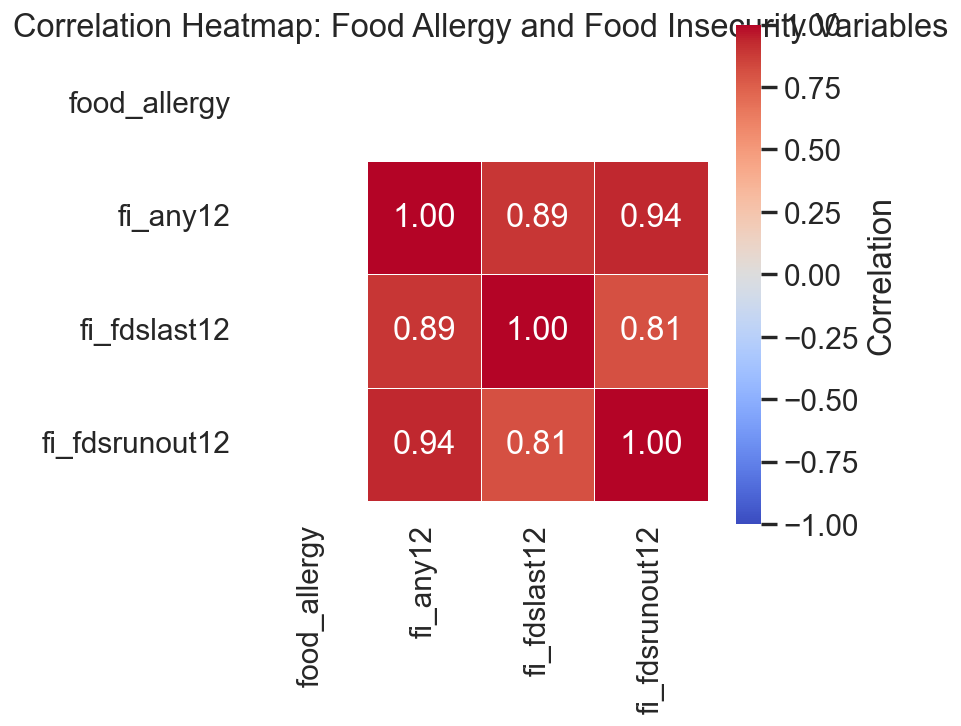

In [241]:
# Visualization: Correlation Heatmap for Binary Variables
# Creates missing binary variables from combined, then plots correlation heatmap.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white", context="talk")

work = combined.copy()

# 1) food_allergy 생성
work["food_allergy"] = pd.to_numeric(work["CURFOOD_C"], errors="coerce").map({1: 1, 2: 0})


# 2) fi_fdslast12 생성
work["fi_fdslast12"] = pd.to_numeric(work["FDSLAST_C"], errors="coerce").map({1: 1, 2: 1, 3: 0})


# 3) fi_fdsrunout12 생성
work["fi_fdsrunout12"] = pd.to_numeric(work["FDSRUNOUT_C"], errors="coerce").map({1: 1, 2: 1, 3: 0})

# 4) fi_any12 생성
work["fi_any12"] = work[["fi_fdslast12", "fi_fdsrunout12"]].max(axis=1)

# 분석용 데이터
vars_bin = ["food_allergy", "fi_any12", "fi_fdslast12", "fi_fdsrunout12"]
plot_df = work[vars_bin].apply(pd.to_numeric, errors="coerce").dropna()
plot_df = plot_df[plot_df[vars_bin].isin([0, 1]).all(axis=1)]

corr = plot_df.corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"},
    ax=ax,
)
ax.set_title("Correlation Heatmap: Food Allergy and Food Insecurity Variables")
plt.tight_layout()
plt.show()


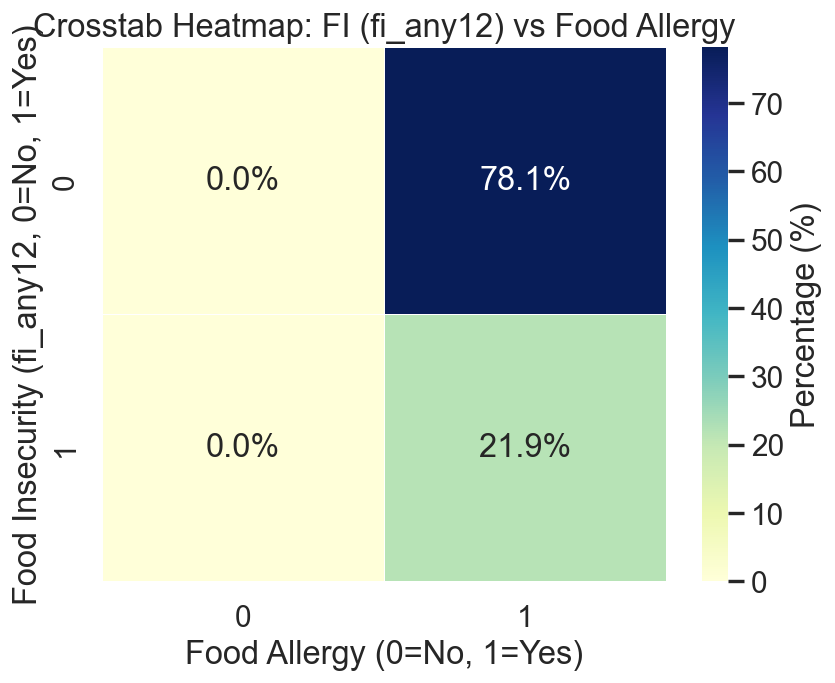